In [1]:
import os
import re
import math
import random
from pathlib import Path
from collections import Counter, defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xml.etree.ElementTree as ET

from tqdm.auto import tqdm

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

random.seed(42)
np.random.seed(42)


In [2]:
DATASET_ROOT = Path(r"F:\DhakaDrive")
ANN_ROOT = DATASET_ROOT / "annotations" / "manual"
VIDEO_ROOT = DATASET_ROOT / "videos"

# Put processed data on F drive
OUTPUT_ROOT = Path(r"F:\DhakaDrive_processed")
EDA_DIR = OUTPUT_ROOT / "eda"
YOLO_IMAGES_DIR = OUTPUT_ROOT / "images"
YOLO_LABELS_DIR = OUTPUT_ROOT / "labels"

for p in [OUTPUT_ROOT, EDA_DIR, YOLO_IMAGES_DIR, YOLO_LABELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    "private-car",
    "cng",
    "bus",
    "bicycle",
    "truck",
    "paddle-rickshaw",
    "microbus",
    "van",
    "bangla-tesla",
    "bike",
    "pedestrian",
    "crosswalk",
]

CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {idx: name for name, idx in CLASS_TO_ID.items()}

IMG_W = 2592
IMG_H = 1944

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("Classes:", CLASS_TO_ID)


OUTPUT_ROOT: F:\DhakaDrive_processed
Classes: {'private-car': 0, 'cng': 1, 'bus': 2, 'bicycle': 3, 'truck': 4, 'paddle-rickshaw': 5, 'microbus': 6, 'van': 7, 'bangla-tesla': 8, 'bike': 9, 'pedestrian': 10, 'crosswalk': 11}


In [3]:
def normalize_name(name: str) -> str:
    if name is None:
        return ""
    name = str(name).strip().lower()
    name = name.replace("_", "-")
    name = re.sub(r"\s+", "-", name)
    return name

def find_matching_video(xml_path: Path) -> Path | None:
    split = xml_path.parent.name
    stem = xml_path.stem
    candidates = [
        VIDEO_ROOT / split / f"{stem}.MP4",
        VIDEO_ROOT / split / f"{stem}.mp4",
        VIDEO_ROOT / split / f"{stem}.MOV",
        VIDEO_ROOT / split / f"{stem}.mov",
        VIDEO_ROOT / split / f"{stem}.AVI",
        VIDEO_ROOT / split / f"{stem}.avi",
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

def collect_pairs():
    pairs = []
    missing_videos = []
    for xml_path in sorted(ANN_ROOT.rglob("*.xml")):
        if xml_path.parent.name not in {"train", "val", "test"}:
            continue
        video_path = find_matching_video(xml_path)
        if video_path is None:
            missing_videos.append(xml_path)
            continue
        pairs.append({
            "split": xml_path.parent.name,
            "xml_path": xml_path,
            "video_path": video_path,
            "stem": xml_path.stem,
        })
    return pairs, missing_videos

pairs, missing_videos = collect_pairs()
print("Matched pairs:", len(pairs))
print("Missing videos:", len(missing_videos))


Matched pairs: 29
Missing videos: 0


In [4]:
def get_xml_text(root, xpath, default=None):
    node = root.find(xpath)
    return node.text.strip() if node is not None and node.text else default

def get_box_attribute(box, attr_name):
    for attr in box.findall("attribute"):
        if normalize_name(attr.get("name")) == normalize_name(attr_name):
            return attr.text.strip() if attr.text else None
    return None

def resolve_class_name(track_label, box):
    track_label = normalize_name(track_label)

    if track_label in CLASS_TO_ID:
        return track_label

    # Main DhakaDrive schema: label="vehicle", subtype in attribute V_Type
    if track_label == "vehicle":
        v_type = normalize_name(get_box_attribute(box, "V_Type"))
        if v_type in CLASS_TO_ID:
            return v_type
        return None

    return None

def parse_xml_file(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    split = xml_path.parent.name
    source_video = get_xml_text(root, "./meta/task/source", default=xml_path.stem)

    rows = []
    for track in root.findall(".//track"):
        track_id = track.get("id")
        track_label = track.get("label", "")

        for box in track.findall("box"):
            if box.get("outside") == "1":
                continue

            cls_name = resolve_class_name(track_label, box)
            if cls_name is None:
                continue

            rows.append({
                "split": split,
                "xml_name": xml_path.name,
                "video_name": f"{xml_path.stem}.MP4",
                "source_video": source_video,
                "track_id": track_id,
                "track_label": track_label,
                "class_name": cls_name,
                "class_id": CLASS_TO_ID[cls_name],
                "frame": int(box.get("frame")),
                "xtl": float(box.get("xtl")),
                "ytl": float(box.get("ytl")),
                "xbr": float(box.get("xbr")),
                "ybr": float(box.get("ybr")),
                "occluded": box.get("occluded"),
                "outside": box.get("outside"),
                "keyframe": box.get("keyframe"),
                "z_order": box.get("z_order"),
                "occlusion_attr": get_box_attribute(box, "Occlusion"),
                "parking_attr": get_box_attribute(box, "Parking"),
                "v_type_attr": get_box_attribute(box, "V_Type"),
            })

    return pd.DataFrame(rows)


In [5]:
all_dfs = []
bad_xmls = []

for item in tqdm(pairs, desc="Parsing XMLs"):
    try:
        df = parse_xml_file(item["xml_path"])
        if not df.empty:
            all_dfs.append(df)
    except Exception as e:
        bad_xmls.append((item["xml_path"], str(e)))

annotations_df = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()

print("Total rows:", len(annotations_df))
print("Bad XMLs:", len(bad_xmls))


Parsing XMLs:   0%|          | 0/29 [00:00<?, ?it/s]

Total rows: 271542
Bad XMLs: 0


In [6]:
annotations_df["width_px"] = annotations_df["xbr"] - annotations_df["xtl"]
annotations_df["height_px"] = annotations_df["ybr"] - annotations_df["ytl"]
annotations_df["area_px"] = annotations_df["width_px"] * annotations_df["height_px"]
annotations_df["aspect_ratio"] = annotations_df["width_px"] / annotations_df["height_px"].replace(0, np.nan)

# Conservative cleaning
clean_df = annotations_df.copy()
clean_df["xtl"] = clean_df["xtl"].clip(0, IMG_W - 1)
clean_df["ytl"] = clean_df["ytl"].clip(0, IMG_H - 1)
clean_df["xbr"] = clean_df["xbr"].clip(0, IMG_W - 1)
clean_df["ybr"] = clean_df["ybr"].clip(0, IMG_H - 1)

clean_df["width_px"] = clean_df["xbr"] - clean_df["xtl"]
clean_df["height_px"] = clean_df["ybr"] - clean_df["ytl"]
clean_df["area_px"] = clean_df["width_px"] * clean_df["height_px"]

MIN_BOX_WIDTH = 5
MIN_BOX_HEIGHT = 5
MIN_BOX_AREA = 25

before = len(clean_df)
clean_df = clean_df[
    (clean_df["width_px"] >= MIN_BOX_WIDTH) &
    (clean_df["height_px"] >= MIN_BOX_HEIGHT) &
    (clean_df["area_px"] >= MIN_BOX_AREA)
].copy()
after = len(clean_df)

print("Before filtering:", before)
print("After filtering:", after)
print("Removed:", before - after)


Before filtering: 271542
After filtering: 271538
Removed: 4


In [7]:
summary = {
    "num_xml_files": len(pairs),
    "num_annotations": len(clean_df),
    "num_clips": clean_df["xml_name"].nunique(),
    "num_classes_found": clean_df["class_name"].nunique(),
    "num_frames": clean_df["frame"].nunique(),
}
pd.DataFrame([summary])


,num_xml_files,num_annotations,num_clips,num_classes_found,num_frames
0,29,271538,29,12,5400


C:\Users\User\AppData\Local\Temp\ipykernel_7508\4260683623.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")


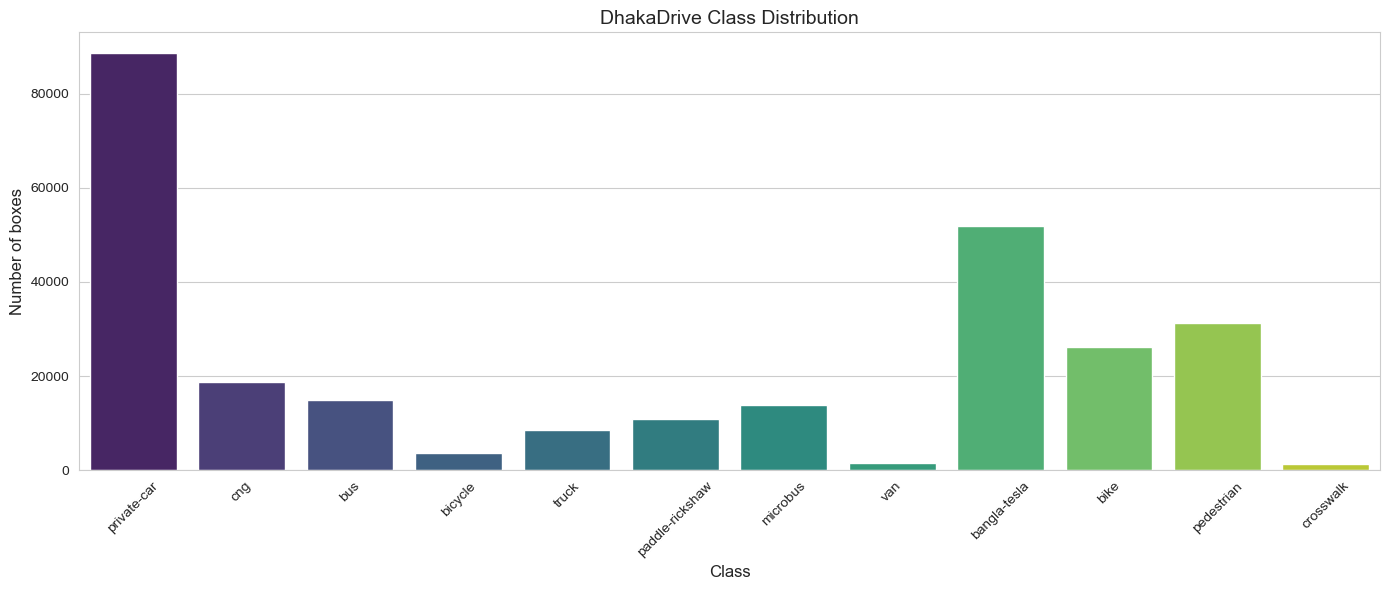

class_name
private-car        88590
cng                18803
bus                14866
bicycle             3699
truck               8507
paddle-rickshaw    10911
microbus           13928
van                 1502
bangla-tesla       51827
bike               26217
pedestrian         31287
crosswalk           1401
Name: count, dtype: int64

In [8]:
class_counts = clean_df["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)

plt.figure(figsize=(14, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("DhakaDrive Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of boxes")
plt.tight_layout()
plt.savefig(EDA_DIR / "class_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

class_counts


In [9]:
box_stats = clean_df[["width_px", "height_px", "area_px", "aspect_ratio"]].describe()
box_stats


,width_px,height_px,area_px,aspect_ratio
count,271538.000000,271538.000000,2.715380e+05,271538.000000
mean,259.768781,292.819904,1.089041e+05,0.939112
std,201.158544,211.685524,1.726095e+05,0.455761
min,11.800000,27.820000,8.087274e+02,0.020861
25%,124.430000,143.362500,1.821450e+04,0.696008
50%,204.000000,233.510000,4.845288e+04,0.882025
75%,329.260000,378.497500,1.205280e+05,1.110684
max,2475.830000,1866.460000,2.440173e+06,28.607143


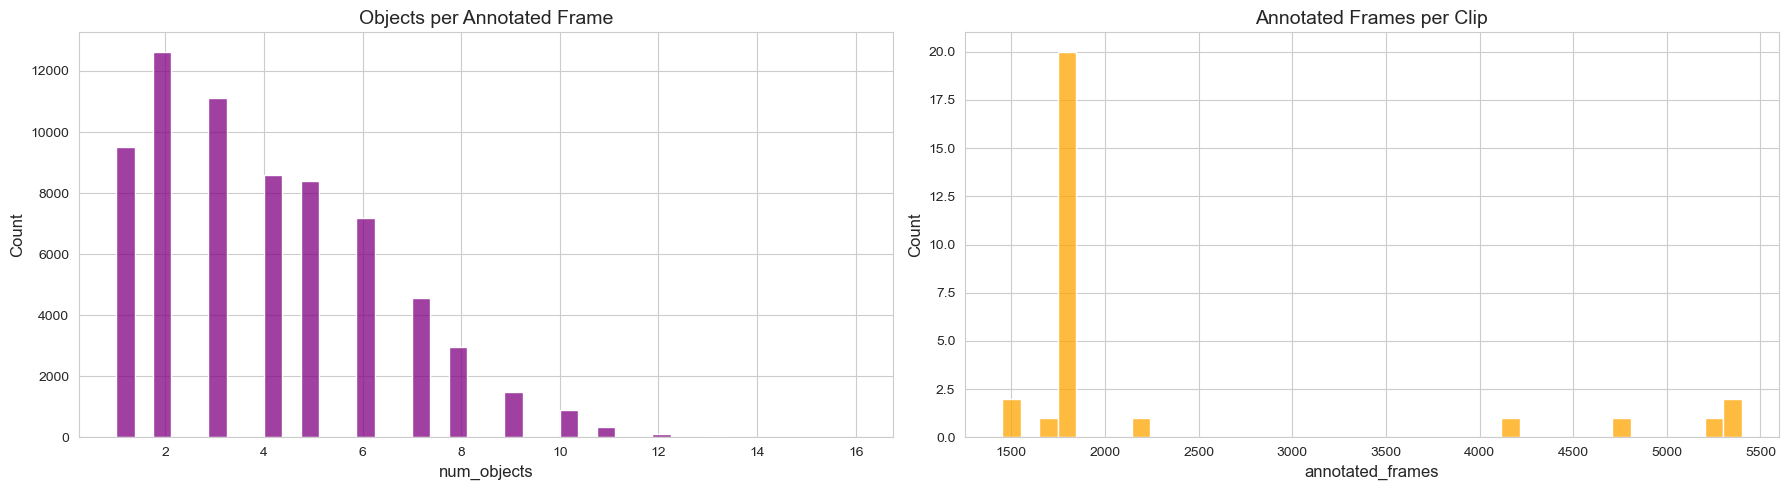

,annotated_frames
count,29.000000
mean,2339.172414
std,1261.105299
min,1450.000000
25%,1800.000000
50%,1800.000000
75%,1800.000000
max,5400.000000


In [10]:
frames_per_clip = clean_df.groupby("xml_name")["frame"].nunique().reset_index(name="annotated_frames")
objects_per_frame = clean_df.groupby(["xml_name", "frame"]).size().reset_index(name="num_objects")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(objects_per_frame["num_objects"], bins=40, ax=axes[0], color="purple")
axes[0].set_title("Objects per Annotated Frame")

sns.histplot(frames_per_clip["annotated_frames"], bins=40, ax=axes[1], color="orange")
axes[1].set_title("Annotated Frames per Clip")

plt.tight_layout()
plt.savefig(EDA_DIR / "frame_density.png", dpi=200, bbox_inches="tight")
plt.show()

frames_per_clip.describe()


In [11]:
rare_classes = ["van", "bicycle", "crosswalk"]

suspect_parts = []
for cls in rare_classes:
    d = clean_df[clean_df["class_name"] == cls].copy()
    if d.empty:
        continue

    q1_area = d["area_px"].quantile(0.01)
    q99_area = d["area_px"].quantile(0.99)
    q1_ar = d["aspect_ratio"].quantile(0.01)
    q99_ar = d["aspect_ratio"].quantile(0.99)

    bad = d[
        (d["area_px"] <= q1_area) |
        (d["area_px"] >= q99_area) |
        (d["aspect_ratio"] <= q1_ar) |
        (d["aspect_ratio"] >= q99_ar)
    ]
    suspect_parts.append(bad)

suspect_df = pd.concat(suspect_parts, ignore_index=True) if suspect_parts else pd.DataFrame()

print("Suspicious rare boxes:", len(suspect_df))
suspect_df[["xml_name", "frame", "class_name", "xtl", "ytl", "xbr", "ybr", "area_px", "aspect_ratio"]].head(20)


Suspicious rare boxes: 304


,xml_name,frame,class_name,xtl,ytl,xbr,ybr,area_px,aspect_ratio
0,BTP_20251114_155237_143770F.xml,1051,van,1206.34,1160.46,1297.63,1266.78,9705.9528,0.858634
1,BTP_20251114_155237_143770F.xml,1052,van,1205.18,1159.69,1296.48,1266.01,9707.0160,0.858728
2,BTP_20251114_155237_143770F.xml,1053,van,1204.03,1158.92,1295.32,1265.24,9705.9528,0.858634
3,BTP_20251114_155237_143770F.xml,1054,van,1202.87,1158.15,1294.16,1264.46,9705.0399,0.858715
4,BTP_20251114_155237_143770F.xml,1055,van,1202.29,1158.15,1293.59,1264.46,9706.1030,0.858809
5,BTP_20251114_155237_143770F.xml,1056,van,1201.72,1158.15,1293.01,1264.46,9705.0399,0.858715
6,BTP_20251114_155237_143770F.xml,1219,van,0.00,1019.80,831.40,1751.31,608177.4140,1.136553
7,BTP_20251114_155237_143770F.xml,1220,van,0.00,1023.01,824.99,1754.52,603488.4349,1.127790
8,BTP_20251114_155237_143770F.xml,1221,van,0.00,1026.22,818.57,1757.73,598792.1407,1.119014
9,BTP_20251114_155237_143770F.xml,1222,van,0.00,1037.44,804.14,1768.96,588244.4928,1.099273


In [12]:
train_df = clean_df[clean_df["split"] == "train"].copy()

train_class_freq = train_df["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)

# Final last-pass adjustment:
# Push the weakest classes much higher while lowering the dominant classes further.
CLASS_TARGETS = {
    "private-car": 4200,
    "cng": 12000,
    "bus": 6500,
    "bicycle": 10500,
    "truck": 6000,
    "paddle-rickshaw": 12000,
    "microbus": 6500,
    "van": 12000,
    "bangla-tesla": 4200,
    "bike": 6500,
    "pedestrian": 8000,
    "crosswalk": 12000,
}

POST_EXPORT_CLASS_CAPS = CLASS_TARGETS.copy()
MAX_REPEAT_PER_BOX = 14
MIN_KEEP_PROBABILITY = 0.005

class_weight = pd.Series(
    {cls: CLASS_TARGETS[cls] / max(int(train_class_freq.get(cls, 0)), 1) for cls in CLASS_NAMES}
)
class_weight = class_weight / class_weight[class_weight > 0].mean()

print("Train class frequency:")
print(train_class_freq)
print()
print("Class targets:")
print(pd.Series(CLASS_TARGETS))
print()
print("Class weights:")
print(class_weight.sort_values(ascending=False))


Train class frequency:
class_name
private-car        56624
cng                12019
bus                11813
bicycle             1999
truck               7079
paddle-rickshaw     6139
microbus           11403
van                 1102
bangla-tesla       39792
bike               16705
pedestrian         20019
crosswalk            615
Name: count, dtype: int64

Class targets:
private-car         4200
cng                12000
bus                 6500
bicycle            10500
truck               6000
paddle-rickshaw    12000
microbus            6500
van                12000
bangla-tesla        4200
bike                6500
pedestrian          8000
crosswalk          12000
dtype: int64

Class weights:
crosswalk          5.636167
van                3.145411
bicycle            1.517240
paddle-rickshaw    0.564627
cng                0.288397
truck              0.244826
microbus           0.164654
bus                0.158939
pedestrian         0.115432
bike               0.112394
bangla-tesla   

In [13]:
def build_box_level_balanced_manifest(
    df,
    class_freq,
    class_targets,
    class_weight,
    max_repeat=14,
    min_keep_probability=0.005,
):
    train_boxes = df[df["split"] == "train"].copy()

    frame_box_counts = train_boxes.groupby(["xml_name", "frame"]).size().rename("boxes_in_frame")
    train_boxes = train_boxes.join(frame_box_counts, on=["xml_name", "frame"])

    train_boxes["class_freq"] = train_boxes["class_name"].map(class_freq).fillna(0).astype(int)
    train_boxes["target_count"] = train_boxes["class_name"].map(class_targets).fillna(0).astype(int)
    train_boxes["class_weight"] = train_boxes["class_name"].map(class_weight).fillna(0.0).astype(float)

    train_boxes["balance_ratio"] = train_boxes["target_count"] / train_boxes["class_freq"].replace(0, np.nan)
    train_boxes["balance_ratio"] = train_boxes["balance_ratio"].replace([np.inf, -np.inf], 0).fillna(0.0)

    over_target = train_boxes["class_freq"] > train_boxes["target_count"]

    train_boxes["keep_probability"] = np.where(
        over_target,
        np.maximum(train_boxes["target_count"] / train_boxes["class_freq"], min_keep_probability),
        1.0,
    )

    # Extra boost for the rare classes by applying both ratio and class-weight.
    train_boxes["repeat_count"] = np.where(
        over_target,
        1,
        np.clip(np.ceil(train_boxes["balance_ratio"] * train_boxes["class_weight"] * 1.15), 1, max_repeat),
    ).astype(int)

    train_boxes["box_index"] = train_boxes.index
    train_boxes["target_count"] = train_boxes["target_count"].astype(int)

    cols = [
        "split", "xml_name", "frame", "box_index", "class_name",
        "class_freq", "target_count", "class_weight",
        "keep_probability", "repeat_count", "balance_ratio", "boxes_in_frame"
    ]

    return train_boxes[cols].reset_index(drop=True)

balanced_manifest = build_box_level_balanced_manifest(
    train_df,
    train_class_freq,
    CLASS_TARGETS,
    class_weight,
    max_repeat=MAX_REPEAT_PER_BOX,
    min_keep_probability=MIN_KEEP_PROBABILITY,
)

print("Original train boxes:", len(train_df))
print("Balanced box manifest rows:", len(balanced_manifest))
print()
print(
    balanced_manifest.groupby("class_name")
    .agg(
        source_boxes=("box_index", "count"),
        target_count=("target_count", "first"),
        total_copies=("repeat_count", "sum"),
        avg_repeat_count=("repeat_count", "mean"),
        avg_keep_probability=("keep_probability", "mean"),
    )
    .sort_values("total_copies", ascending=False)
)


Original train boxes: 185309
Balanced box manifest rows: 185309

                 source_boxes  target_count  total_copies  avg_repeat_count  \
class_name                                                                    
private-car             56624          4200         56624               1.0   
bangla-tesla            39792          4200         39792               1.0   
pedestrian              20019          8000         20019               1.0   
bicycle                  1999         10500         19990              10.0   
bike                    16705          6500         16705               1.0   
van                      1102         12000         15428              14.0   
paddle-rickshaw          6139         12000         12278               2.0   
cng                     12019         12000         12019               1.0   
bus                     11813          6500         11813               1.0   
microbus                11403          6500         11403         

In [14]:
clip_stats_rows = []
for xml_name, g in train_df.groupby("xml_name"):
    class_hist = g["class_name"].value_counts().to_dict()
    clip_stats_rows.append({"xml_name": xml_name, "class_hist": class_hist})

clip_stats = pd.DataFrame(clip_stats_rows)

def clip_rarity_score(class_hist):
    if not isinstance(class_hist, dict):
        return 0.0

    score = 0.0
    for cls, cnt in class_hist.items():
        score += (1.0 / max(cnt, 1)) * float(class_weight.get(cls, 1.0))
    return score

clip_stats["rarity_score"] = clip_stats["class_hist"].apply(clip_rarity_score)

def choose_stride(rarity_score):
    if rarity_score > 0.18:
        return 1
    elif rarity_score > 0.10:
        return 2
    else:
        return 5

clip_stats["stride"] = clip_stats["rarity_score"].apply(choose_stride)
clip_stats.sort_values("rarity_score", ascending=False).head(10)


,xml_name,class_hist,rarity_score,stride
5,BTP_20251114_152337_143741F.xml,"{'bangla-tesla': 3230, 'private-car': 2655, 'c...",0.188394,1
4,BTP_20251114_152237_143740F.xml,"{'bangla-tesla': 2433, 'private-car': 1923, 'c...",0.146636,2
9,BTP_20251114_160337_143781F.xml,"{'bike': 3150, 'bangla-tesla': 2636, 'cng': 20...",0.116925,2
7,BTP_20251114_152637_143744F.xml,"{'bangla-tesla': 5953, 'private-car': 657, 'pe...",0.073763,5
0,BTP_20251101_220743_002275F.xml,"{'bangla-tesla': 5169, 'microbus': 3476, 'bus'...",0.065074,5
11,BTP_20251114_160937_143787F.xml,"{'private-car': 3082, 'bus': 664, 'microbus': ...",0.050209,5
8,BTP_20251114_152738_143745F.xml,"{'bangla-tesla': 5838, 'pedestrian': 1740, 'bi...",0.047448,5
16,BTP_20251114_171046_143811F.xml,"{'pedestrian': 4662, 'private-car': 3018, 'pad...",0.044857,5
2,BTP_20251101_222543_002281F.xml,"{'private-car': 3977, 'pedestrian': 1990, 'ban...",0.034803,5
3,BTP_20251108_144628_002349F.xml,"{'private-car': 14670, 'bangla-tesla': 7223, '...",0.025537,5


In [15]:
balanced_class_summary = (
    balanced_manifest.groupby("class_name")
    .agg(
        source_boxes=("box_index", "count"),
        target_count=("target_count", "first"),
        total_copies=("repeat_count", "sum"),
        avg_repeat_count=("repeat_count", "mean"),
        avg_keep_probability=("keep_probability", "mean"),
    )
    .sort_values("total_copies", ascending=False)
)

balanced_class_summary


,source_boxes,target_count,total_copies,avg_repeat_count,avg_keep_probability
class_name,,,,,
private-car,56624,4200,56624,1.0,0.074173
bangla-tesla,39792,4200,39792,1.0,0.105549
pedestrian,20019,8000,20019,1.0,0.399620
bicycle,1999,10500,19990,10.0,1.000000
bike,16705,6500,16705,1.0,0.389105
van,1102,12000,15428,14.0,1.000000
paddle-rickshaw,6139,12000,12278,2.0,1.000000
cng,12019,12000,12019,1.0,0.998419
bus,11813,6500,11813,1.0,0.550241


In [16]:
EXPORT_RNG_SEED = 42


def clip_bbox(x1, y1, x2, y2, w, h):
    x1 = max(0, min(float(x1), w - 1))
    y1 = max(0, min(float(y1), h - 1))
    x2 = max(0, min(float(x2), w - 1))
    y2 = max(0, min(float(y2), h - 1))
    return x1, y1, x2, y2


def bbox_to_yolo(x1, y1, x2, y2, img_w, img_h):
    xc = ((x1 + x2) / 2.0) / img_w
    yc = ((y1 + y2) / 2.0) / img_h
    bw = (x2 - x1) / img_w
    bh = (y2 - y1) / img_h
    return xc, yc, bw, bh


def read_frame_from_video(video_path: Path, frame_idx: int):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read frame {frame_idx} from {video_path}")
    return frame


def build_frame_manifest_from_box_manifest(box_manifest):
    frame_manifest = (
        box_manifest.groupby(["split", "xml_name", "frame"])
        .agg(
            repeat_count=("repeat_count", "max"),
            keep_probability=("keep_probability", "min"),
            dominant_class=("class_name", lambda s: s.value_counts().idxmax()),
            class_count=("class_name", "nunique"),
        )
        .reset_index()
    )
    return frame_manifest


def enforce_class_cap_on_train_split(images_dir, labels_dir, class_caps):
    train_img_dir = images_dir / "train"
    train_lbl_dir = labels_dir / "train"

    samples = []
    class_totals = Counter()

    for lbl_path in sorted(train_lbl_dir.glob("*.txt")):
        counts = Counter()
        with open(lbl_path, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls_id = int(parts[0])
                    counts[cls_id] += 1
        if not counts:
            continue

        class_totals.update(counts)
        samples.append(
            {
                "stem": lbl_path.stem,
                "label_path": lbl_path,
                "image_path": train_img_dir / f"{lbl_path.stem}.jpg",
                "counts": counts,
                "total_boxes": sum(counts.values()),
                "removed": False,
            }
        )

    removed_images = 0
    removed_boxes = 0

    while True:
        over = {}
        for cls_id, total in class_totals.items():
            cap = class_caps.get(ID_TO_CLASS.get(cls_id, str(cls_id)), None)
            if cap is not None and total > cap:
                over[cls_id] = total - cap

        if not over:
            break

        best_idx = None
        best_score = 0.0

        for i, sample in enumerate(samples):
            if sample["removed"]:
                continue

            contrib = 0.0
            for cls_id, excess in over.items():
                class_cap = class_caps.get(ID_TO_CLASS.get(cls_id, str(cls_id)), 1)
                contrib += sample["counts"].get(cls_id, 0) * (excess / max(class_cap, 1))

            if contrib > best_score:
                best_score = contrib
                best_idx = i

        if best_idx is None or best_score <= 0:
            break

        sample = samples[best_idx]
        for cls_id, cnt in sample["counts"].items():
            class_totals[cls_id] -= cnt

        if sample["label_path"].exists():
            sample["label_path"].unlink()
        if sample["image_path"].exists():
            sample["image_path"].unlink()

        sample["removed"] = True
        removed_images += 1
        removed_boxes += sample["total_boxes"]

    return {
        "removed_images": removed_images,
        "removed_boxes": removed_boxes,
        "final_class_totals": class_totals,
    }


def save_yolo_dataset(
    df,
    pairs,
    out_images_dir,
    out_labels_dir,
    balanced_manifest=None,
    class_caps=None,
):
    stats = {
        "videos_processed": 0,
        "frames_saved": 0,
        "labels_saved": 0,
        "boxes_saved": 0,
        "skipped_unknown_class": 0,
        "skipped_invalid_box": 0,
        "failed_videos": 0,
        "dropped_by_keep_probability": 0,
        "removed_images_by_cap": 0,
        "removed_boxes_by_cap": 0,
    }

    pairs_map = {(p["split"], p["stem"]): p for p in pairs}
    rng = np.random.default_rng(EXPORT_RNG_SEED)

    if balanced_manifest is not None and not balanced_manifest.empty:
        source_manifest = build_frame_manifest_from_box_manifest(balanced_manifest)
    else:
        source_manifest = df.groupby(["split", "xml_name", "frame"]).size().reset_index(name="repeat_count")
        source_manifest["keep_probability"] = 1.0
        source_manifest["dominant_class"] = None
        source_manifest["class_count"] = 0

    for _, row in tqdm(source_manifest.iterrows(), total=len(source_manifest), desc="Exporting YOLO"):
        split = row["split"]
        xml_name = row["xml_name"]
        frame_idx = int(row["frame"])
        stem = Path(xml_name).stem

        pair = pairs_map.get((split, stem))
        if pair is None:
            continue

        if split == "train":
            keep_prob = float(row.get("keep_probability", 1.0))
            if rng.random() > keep_prob:
                stats["dropped_by_keep_probability"] += 1
                continue

        repeat_count = int(row.get("repeat_count", 1))
        repeat_count = max(repeat_count, 1)

        video_path = pair["video_path"]
        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            stats["failed_videos"] += 1
            continue

        stats["videos_processed"] += 1

        split_img_dir = out_images_dir / split
        split_lbl_dir = out_labels_dir / split
        split_img_dir.mkdir(parents=True, exist_ok=True)
        split_lbl_dir.mkdir(parents=True, exist_ok=True)

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        cap.release()
        if not ok:
            continue

        h, w = frame.shape[:2]
        frame_boxes = df[
            (df["split"] == split) &
            (df["xml_name"] == xml_name) &
            (df["frame"] == frame_idx)
        ].copy()

        yolo_lines = []
        for _, b in frame_boxes.iterrows():
            cls_name = b["class_name"]
            if cls_name not in CLASS_TO_ID:
                stats["skipped_unknown_class"] += 1
                continue

            x1, y1, x2, y2 = clip_bbox(b["xtl"], b["ytl"], b["xbr"], b["ybr"], w, h)
            bw = x2 - x1
            bh = y2 - y1
            if bw < MIN_BOX_WIDTH or bh < MIN_BOX_HEIGHT:
                stats["skipped_invalid_box"] += 1
                continue

            xc, yc, bw_n, bh_n = bbox_to_yolo(x1, y1, x2, y2, w, h)
            yolo_lines.append(f"{CLASS_TO_ID[cls_name]} {xc:.6f} {yc:.6f} {bw_n:.6f} {bh_n:.6f}")

        if not yolo_lines:
            continue

        for copy_idx in range(repeat_count):
            copy_suffix = f"_r{copy_idx + 1:02d}" if repeat_count > 1 else ""
            img_name = f"{stem}_f{frame_idx:06d}{copy_suffix}.jpg"
            lbl_name = f"{stem}_f{frame_idx:06d}{copy_suffix}.txt"
            img_path = split_img_dir / img_name
            lbl_path = split_lbl_dir / lbl_name
            cv2.imwrite(str(img_path), frame, [int(cv2.IMWRITE_JPEG_QUALITY), 95])
            with open(lbl_path, "w", encoding="utf-8") as f:
                f.write("\n".join(yolo_lines))
            stats["frames_saved"] += 1
            stats["labels_saved"] += 1
            stats["boxes_saved"] += len(yolo_lines)

    if class_caps is not None:
        cap_stats = enforce_class_cap_on_train_split(out_images_dir, out_labels_dir, class_caps)
        stats["removed_images_by_cap"] = cap_stats["removed_images"]
        stats["removed_boxes_by_cap"] = cap_stats["removed_boxes"]

    return stats


In [17]:
# Export ONLY val/test with target ratio: Train 70%, Val 15%, Test 15%
# Train already exists with 12,165 images/labels and will NOT be re-exported.

from collections import Counter

TRAIN_LABELS_DIR = YOLO_LABELS_DIR / "train"
train_count = len(list(TRAIN_LABELS_DIR.glob("*.txt")))
if train_count == 0:
    raise RuntimeError(f"No train labels found at {TRAIN_LABELS_DIR}")

# If train is 70%, then each of val and test should be (15/70) * train
target_per_split = int(round(train_count * (15 / 70)))
print(f"Train count: {train_count}")
print(f"Target val count: {target_per_split}")
print(f"Target test count: {target_per_split}")

non_train_df = clean_df[clean_df["split"].isin(["val", "test"])].copy()

# Build per-frame table for val/test and score frames to preserve rare-class coverage
frame_rows = []
for (split, xml_name, frame), g in non_train_df.groupby(["split", "xml_name", "frame"]):
    cls_counts = g["class_name"].value_counts().to_dict()
    dominant_class = g["class_name"].value_counts().idxmax()
    frame_rows.append({
        "split": split,
        "xml_name": xml_name,
        "frame": int(frame),
        "class_hist": cls_counts,
        "dominant_class": dominant_class,
    })

frame_df = pd.DataFrame(frame_rows)
if frame_df.empty:
    raise RuntimeError("No val/test frames available to export.")

split_selected = {}
for split_name in ["val", "test"]:
    sdf = frame_df[frame_df["split"] == split_name].copy()
    if sdf.empty:
        split_selected[split_name] = sdf
        continue

    split_class_freq = non_train_df[non_train_df["split"] == split_name]["class_name"].value_counts()

    def rarity_score(class_hist):
        score = 0.0
        for cls, cnt in class_hist.items():
            score += (1.0 / max(int(split_class_freq.get(cls, 1)), 1)) * cnt
        return score

    sdf["rarity_score"] = sdf["class_hist"].apply(rarity_score)
    weights = sdf["rarity_score"].to_numpy(dtype=float)
    weights = np.clip(weights, 1e-12, None)
    weights = weights / weights.sum()

    k = min(target_per_split, len(sdf))
    chosen_idx = np.random.default_rng(EXPORT_RNG_SEED).choice(sdf.index.to_numpy(), size=k, replace=False, p=weights)
    split_selected[split_name] = sdf.loc[chosen_idx].copy()

selected_frames_df = pd.concat([split_selected["val"], split_selected["test"]], ignore_index=True)
print("Selected frames:")
print(selected_frames_df["split"].value_counts())

selected_manifest = selected_frames_df[["split", "xml_name", "frame", "dominant_class"]].copy()
selected_manifest = selected_manifest.rename(columns={"dominant_class": "class_name"})
selected_manifest["repeat_count"] = 1
selected_manifest["keep_probability"] = 1.0
selected_manifest["box_index"] = np.arange(len(selected_manifest), dtype=int)
selected_manifest["class_freq"] = 1
selected_manifest["target_count"] = 1
selected_manifest["class_weight"] = 1.0
selected_manifest["balance_ratio"] = 1.0
selected_manifest["boxes_in_frame"] = 1

export_stats_valtest = save_yolo_dataset(
    df=non_train_df,
    pairs=pairs,
    out_images_dir=YOLO_IMAGES_DIR,
    out_labels_dir=YOLO_LABELS_DIR,
    balanced_manifest=selected_manifest,
    class_caps=None,
)

print("Val/Test export stats:", export_stats_valtest)
print("Train export skipped intentionally.")


Train count: 12165
Target val count: 2607
Target test count: 2607
Selected frames:
split
val     2607
test    2607
Name: count, dtype: int64


Exporting YOLO:   0%|          | 0/5214 [00:00<?, ?it/s]

Val/Test export stats: {'videos_processed': 5214, 'frames_saved': 5214, 'labels_saved': 5214, 'boxes_saved': 26053, 'skipped_unknown_class': 0, 'skipped_invalid_box': 0, 'failed_videos': 0, 'dropped_by_keep_probability': 0, 'removed_images_by_cap': 0, 'removed_boxes_by_cap': 0}
Train export skipped intentionally.


In [18]:
data_yaml_path = OUTPUT_ROOT / "data.yaml"

yaml_text = f"""path: {OUTPUT_ROOT.as_posix()}
train: images/train
val: images/val
test: images/test

nc: {len(CLASS_NAMES)}
names:
"""
for i, name in enumerate(CLASS_NAMES):
    yaml_text += f"  {i}: {name}\n"

with open(data_yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_text)

print(data_yaml_path)
print(yaml_text)


F:\DhakaDrive_processed\data.yaml
path: F:/DhakaDrive_processed
train: images/train
val: images/val
test: images/test

nc: 12
names:
  0: private-car
  1: cng
  2: bus
  3: bicycle
  4: truck
  5: paddle-rickshaw
  6: microbus
  7: van
  8: bangla-tesla
  9: bike
  10: pedestrian
  11: crosswalk



train: images=12165, labels=12165, boxes=35877
val: images=2607, labels=2607, boxes=12020
test: images=2607, labels=2607, boxes=14033

Sample ratio (%) by split:
   split  count  ratio_percent
2   test   2607      15.000863
0  train  12165      69.998274
1    val   2607      15.000863


C:\Users\User\AppData\Local\Temp\ipykernel_7508\2484368408.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_series.index, y=train_series.values, palette="cubehelix")


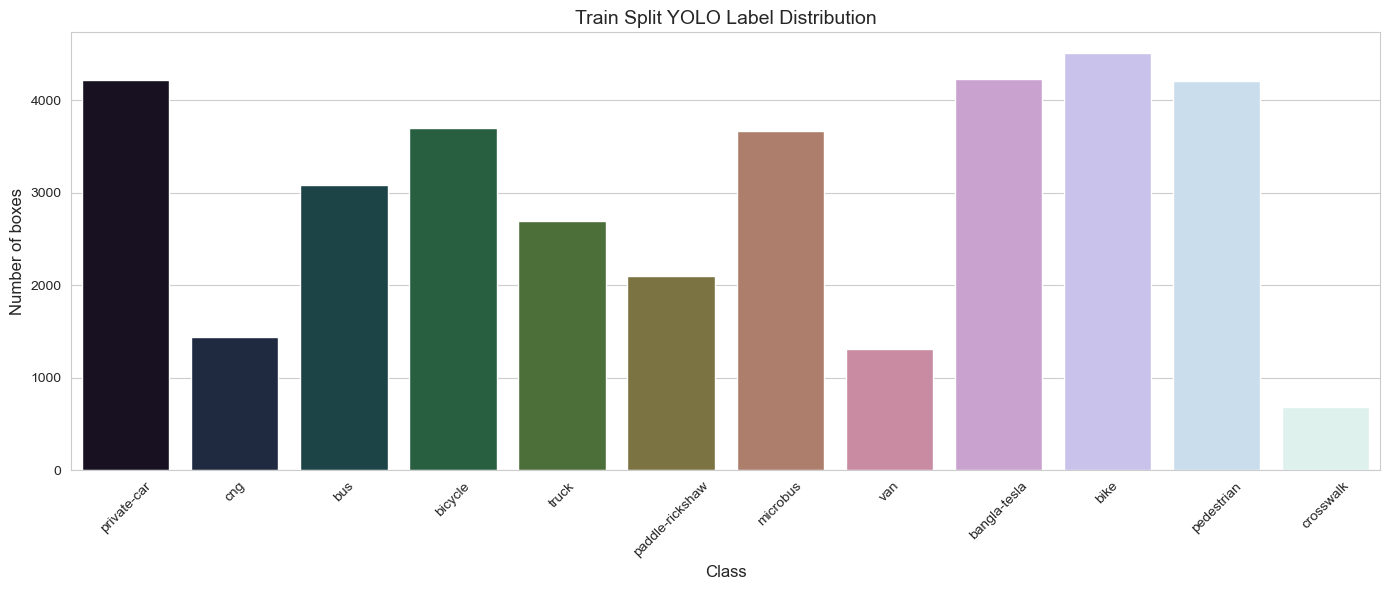

,train,val,test
private-car,4219,3562,3875
cng,1445,1029,993
bus,3085,238,802
bicycle,3701,502,326
truck,2698,500,350
paddle-rickshaw,2100,368,1346
microbus,3665,1048,223
van,1316,0,287
bangla-tesla,4234,1303,2138
bike,4511,1255,1230


In [19]:
# Verify exported labels/images for all splits and ratio targets
split_label_counts = {}
split_counts = {}
for split_name in ["train", "val", "test"]:
    lbl_root = YOLO_LABELS_DIR / split_name
    img_root = YOLO_IMAGES_DIR / split_name

    label_files = list(lbl_root.rglob("*.txt")) if lbl_root.exists() else []
    image_files = list(img_root.rglob("*.jpg")) if img_root.exists() else []

    counts = Counter()
    for lbl_file in label_files:
        with open(lbl_file, "r", encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    counts[int(parts[0])] += 1

    class_series = pd.Series({ID_TO_CLASS[k]: v for k, v in counts.items()}).reindex(CLASS_NAMES, fill_value=0)
    split_label_counts[split_name] = class_series
    split_counts[split_name] = len(label_files)

    print(f"{split_name}: images={len(image_files)}, labels={len(label_files)}, boxes={int(class_series.sum())}")

total_samples = sum(split_counts.values()) if sum(split_counts.values()) > 0 else 1
ratio_df = pd.DataFrame([
    {"split": s, "count": c, "ratio_percent": (c / total_samples) * 100}
    for s, c in split_counts.items()
]).sort_values("split")

print("\nSample ratio (%) by split:")
print(ratio_df)

train_series = split_label_counts["train"]
plt.figure(figsize=(14, 6))
sns.barplot(x=train_series.index, y=train_series.values, palette="cubehelix")
plt.xticks(rotation=45)
plt.title("Train Split YOLO Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of boxes")
plt.tight_layout()
plt.show()

pd.DataFrame(split_label_counts).fillna(0).astype(int)


In [20]:
train_cfg = dict(
    data=str(data_yaml_path),
    imgsz=1280,
    epochs=180,
    batch=4,
    patience=40,
    device=0,
    workers=4,

    mosaic=0.9,
    close_mosaic=16,
    mixup=0.12,
    copy_paste=0.22,
    fliplr=0.5,
    degrees=9.0,
    translate=0.14,
    scale=0.65,
    shear=3.5,
    perspective=0.0005,
    hsv_h=0.025,
    hsv_s=0.65,
    hsv_v=0.45,
    erasing=0.18,

    label_smoothing=0.10,
    fl_gamma=3.0,

    cache=True,
    rect=False,
    plots=True,
    save=True,
)

train_cfg


{'data': 'F:\\DhakaDrive_processed\\data.yaml',
 'imgsz': 1280,
 'epochs': 180,
 'batch': 4,
 'patience': 40,
 'device': 0,
 'workers': 4,
 'mosaic': 0.9,
 'close_mosaic': 16,
 'mixup': 0.12,
 'copy_paste': 0.22,
 'fliplr': 0.5,
 'degrees': 9.0,
 'translate': 0.14,
 'scale': 0.65,
 'shear': 3.5,
 'perspective': 0.0005,
 'hsv_h': 0.025,
 'hsv_s': 0.65,
 'hsv_v': 0.45,
 'erasing': 0.18,
 'label_smoothing': 0.1,
 'fl_gamma': 3.0,
 'cache': True,
 'rect': False,
 'plots': True,
 'save': True}